# Reverse CNV Prediction

This notebook predicts the carbon number distribution for specific molecular classes given a target Cetane Number (CN). 
Because predicting a high-dimensional composition from a single scalar value is an ill-posed inverse problem, we use a K-Nearest Neighbors (KNN) regressor to interpolate the composition from the closest samples in the training set.

Classes of interest:
- Normal paraffins (`nor_par`)
- Iso paraffins (`iso_par`)
- Aromatics (`mon_aro`, `di_aro`, `nap_aro`)
- Cycloparaffins (`mon_nap`, `di_nap`, `tri_nap`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
data_path = "../keroml_dataset.dat"
df = pd.read_csv(data_path, sep='\t', comment='#')

# Drop rows where cetane number is missing
df = df.dropna(subset=['cetane_number_val'])
print(f"Loaded {len(df)} samples with Cetane Number measurements.")

Loaded 22 samples with Cetane Number measurements.


## Extract & Group Target Features

In [3]:
# Define the molecular classes required
target_groups = {
    'Normal Paraffins': ['nor_par'],
    'Iso Paraffins': ['iso_par'],
    'Aromatics': ['mon_aro', 'di_aro', 'nap_aro'],
    'Cycloparaffins': ['mon_nap', 'di_nap', 'tri_nap']
}

carbon_numbers = [f"c{c:02d}" for c in range(5, 25)]

y_cols = []
grouped_data = {}

for group_name, classes in target_groups.items():
    for c_num in carbon_numbers:
        # Construct exact column names and find which exist in the dataframe
        cols_to_sum = [f"2dgc_{cls}_{c_num}" for cls in classes if f"2dgc_{cls}_{c_num}" in df.columns]
        
        if cols_to_sum:
            new_col = f"{group_name}_{c_num}"
            df[new_col] = df[cols_to_sum].sum(axis=1)
            y_cols.append(new_col)
            
y = df[y_cols]
X = df[['cetane_number_val']]

print(f"Extracted {len(y_cols)} grouped target features.")

Extracted 80 grouped target features.


## Model Training
We will use a K-Nearest Neighbors approach to blend the closest known compositions for a given CN.

In [4]:
# Train a KNN model with distance weighting
model = KNeighborsRegressor(n_neighbors=3, weights='distance')
model.fit(X, y)

# Let's see the range of CN in our dataset
cn_min, cn_max = X['cetane_number_val'].min(), X['cetane_number_val'].max()
print(f"Model trained. Valid CN range in dataset: {cn_min:.1f} to {cn_max:.1f}")

Model trained. Valid CN range in dataset: 15.1 to 66.3


## Predict Carbon Number Distribution for a Given Cetane Number

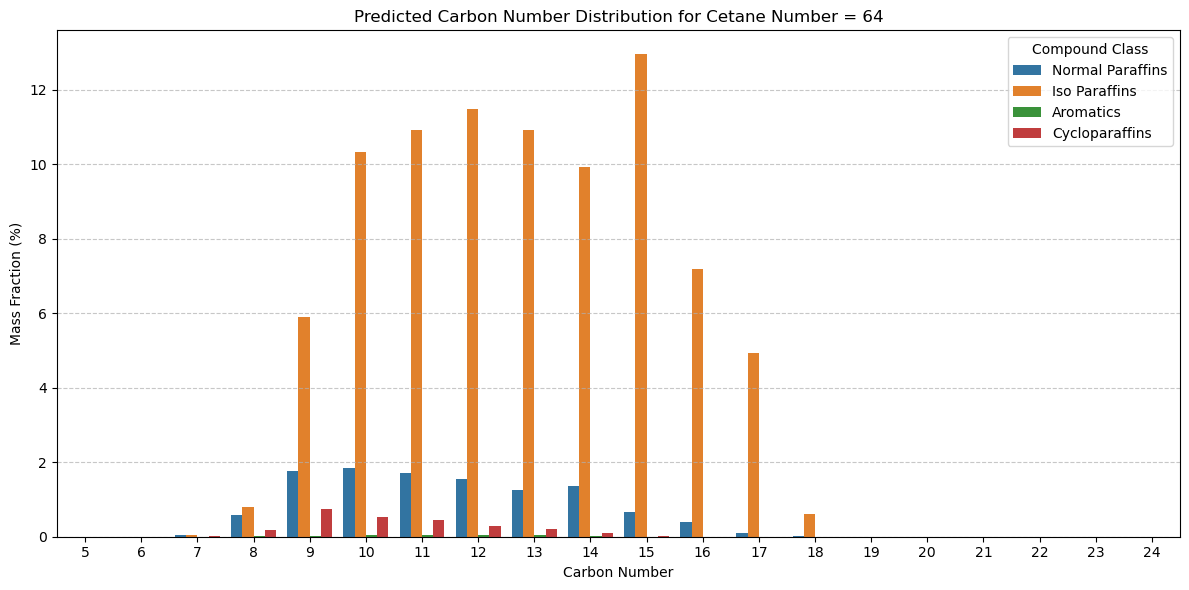

In [10]:
# @Nimal change this value to predict for different CNs
target_cn = 64

# Predict
target_cn_array = np.array([[target_cn]])
predicted_dist = model.predict(target_cn_array)[0]

# Structure the output for plotting
results = []
for idx, col in enumerate(y_cols):
    group = col.split('_c')[0]
    c_num = int(col.split('_c')[1])
    val = predicted_dist[idx]
    results.append({'Group': group, 'Carbon Number': c_num, 'Mass Fraction': val})

res_df = pd.DataFrame(results)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=res_df, x='Carbon Number', y='Mass Fraction', hue='Group')
plt.title(f'Predicted Carbon Number Distribution for Cetane Number = {target_cn}')
plt.ylabel('Mass Fraction (%)')
plt.xlabel('Carbon Number')
plt.legend(title='Compound Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()